In [1]:
import sys 
sys.path.append('../src')
from data_loader import load_data 
from strategy import strategy 
from engine import engine 
from metrics import sharpe 
from strategy import strategy_shift
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from validation import validation


df1 = load_data("AAPL", "2010-1-1","2024-12-30")

p1 = strategy_shift(df1)
p2 = strategy(df1)

PL1,c1 = engine(p1,df1)
PL2,c2 = engine(p2,df1)

/Users/ulysseb/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed


## Look-Ahead Bias Demonstration

We will demonstrate the difference between a strategy with look-ahead bias and one without. Look-ahead bias occurs when a signal calculated at time `t` is used to trade at the same time `t` — which is impossible in practice.

Sharpe without bias : 0.8663074981364334

Sharpe with bias :  1.0023763398848817


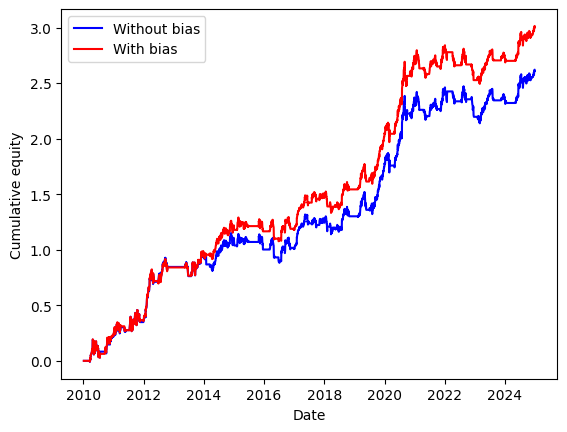

<Figure size 640x480 with 0 Axes>

In [6]:
s1 = sharpe(PL1)
s2= sharpe(PL2)
print("Sharpe without bias :",s1)
print("\nSharpe with bias : ",s2)


plt.plot(df1.index,c1,color = "blue", label = "Without bias")
plt.plot(df1.index,c2,color ="red", label = "With bias")
plt.xlabel("Date")
plt.ylabel("Cumulative equity")
plt.legend()
plt.show()
plt.savefig("../data/look_ahead_bias.png")

**Conclusion:** Look-ahead bias artificially inflates performance — the biased Sharpe is 1.00 vs 0.87 without bias. This gap represents the illusion of alpha that disappears once the implementation is corrected.

## Transaction Costs & Buy-and-Hold Comparison

We now compare the Sharpe ratio with and without transaction costs (5 bps fees + 2 bps slippage), and benchmark against a simple buy-and-hold strategy.

Sharpe with fees : 0.8465375886447981 
sharpe without fees : 0.8663074981364334


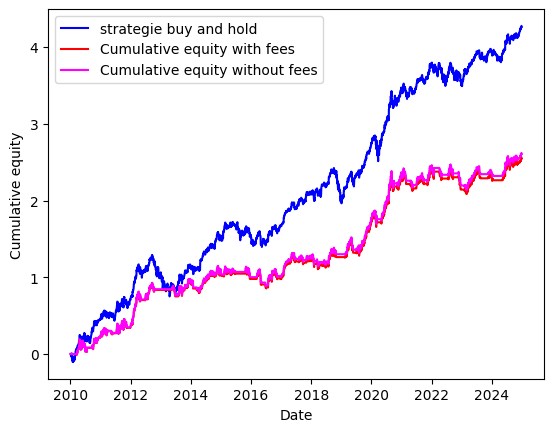

<Figure size 640x480 with 0 Axes>

In [14]:
PL_fees,C_fees = engine(p1,df1,5,2)
c3 = np.cumsum(pd.Series(df1).pct_change())

print("Sharpe with fees :",sharpe(PL_fees),"\nsharpe without fees :",s1)

plt.plot(df1.index,c3, color = "blue", label = "strategie buy and hold")
plt.plot(df1.index,C_fees, color ="red", label ="Cumulative equity with fees")
plt.plot(df1.index,c1,color = "magenta", label="Cumulative equity without fees")
plt.xlabel("Date")
plt.ylabel("Cumulative equity")
plt.legend()
plt.show()
plt.savefig("../data/costs_comparison.png")



**Conclusion:** The MA crossover strategy underperforms buy-and-hold regardless of transaction costs (buy-and-hold cumulative equity: ~4.3 vs strategy: ~2.6). The strategy has a low turnover — cumulative equity is practically equivalent with or without fees — meaning costs are not the main issue. The strategy simply does not generate enough alpha.

## Out-of-Sample Validation

We split the data chronologically: 75% for in-sample (2010–2021), 25% for out-of-sample (2021–2024). No random split — future data must never contaminate past calibration.

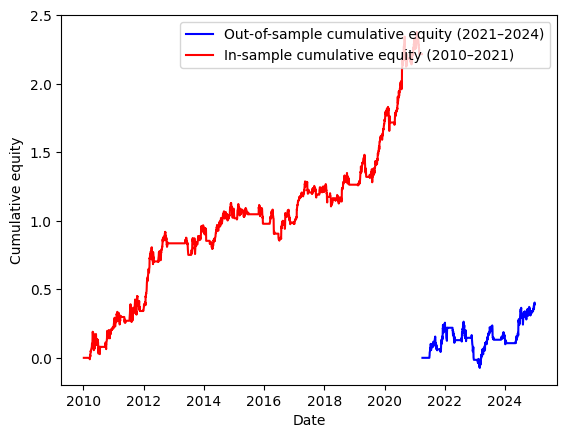

Sharpe on Test Data: 0.5889437147749453


<Figure size 640x480 with 0 Axes>

In [15]:
train,test= validation(df1,0.75)

p_test = strategy_shift(test)
p_train = strategy_shift(train)


PL_test,C_test = engine(p_test,test,5,2)
PL_train,C_train = engine(p_train, train,5,2)



plt.plot(test.index,C_test, color ="blue", label ="Out-of-sample cumulative equity (2021–2024)")
plt.plot(train.index,C_train,color ="red", label="In-sample cumulative equity (2010–2021)")
plt.xlabel("Date")
plt.ylabel("Cumulative equity")
plt.legend()
plt.show()
print("Sharpe on Test Data:", sharpe(PL_test))
plt.savefig("../data/out_of_sample.png") 

**Conclusion:** The strategy's Sharpe drops from 0.87 in-sample to 0.59 out-of-sample. The MA crossover was implicitly calibrated on a strong bull market (2010–2021) and fails to generalize to a more volatile regime (2021–2024). This is the classic overfitting to market conditions — a honest result worth documenting.